In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
from lifelines import AalenJohansenFitter, KaplanMeierFitter

# 0. Configuration
AIDEV_REVISION = "68ed5f4"
DATASET_CUTOFF = pd.Timestamp("2025-08-01 23:59:59", tz="UTC")
PLOT_WINDOW_DAYS = 30
ADMIN_WINDOW_DAYS = 60
INSTANT_MERGE_CUTOFF_DAYS = 1 / 1440

# Launch Jupyter from the repository root.
FIGURES_DIR = Path("figures")
RESULTS_DIR = Path("results")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

target_agents = ["Human", "OpenAI_Codex", "Claude_Code", "Copilot", "Cursor", "Devin"]
agent_labels = {
    "Human": "Human",
    "OpenAI_Codex": "OpenAI Codex",
    "Claude_Code": "Claude Code",
    "Copilot": "Copilot",
    "Cursor": "Cursor",
    "Devin": "Devin",
}
color_map = {
    "Human": "black",
    "OpenAI_Codex": "red",
    "Claude_Code": "orange",
    "Copilot": "blue",
    "Cursor": "green",
    "Devin": "purple",
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.axisbelow": True,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10,
    "figure.titlesize": 16,
    "figure.titleweight": "bold",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

followup_note = (
    f"Follow-up ends at {ADMIN_WINDOW_DAYS} days or the dataset cutoff "
    f"({DATASET_CUTOFF:%Y-%m-%d %H:%M:%S} UTC), whichever comes first. "
    f"First {PLOT_WINDOW_DAYS} days shown."
)


def style_axis(ax, ylabel):
    ax.set_xlabel("Days since PR creation")
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, PLOT_WINDOW_DAYS)
    ax.set_ylim(0, 1.0)
    ax.grid(True, linestyle="--", alpha=0.35)


In [2]:
# 1. Load data and select a common repository pool
df_ai_raw = load_dataset(
    "hao-li/AIDev",
    "pull_request",
    split="train",
    revision=AIDEV_REVISION,
).to_pandas()

df_human_raw = load_dataset(
    "hao-li/AIDev",
    "human_pull_request",
    split="train",
    revision=AIDEV_REVISION,
).to_pandas()

common_repos = set(df_ai_raw["repo_url"].dropna()) & set(
    df_human_raw["repo_url"].dropna()
)

df_valid = pd.concat(
    [df_ai_raw, df_human_raw.assign(agent="Human")],
    ignore_index=True,
)

df_valid = df_valid.loc[
    df_valid["repo_url"].isin(common_repos)
    & df_valid["agent"].isin(target_agents)
].copy()

total_before = len(df_valid)

# AI rows come first, so duplicate PRs retain their agent labels.
df_valid = df_valid.drop_duplicates(
    subset="html_url", keep="first"
).reset_index(drop=True)

print(
    f"Removed {total_before - len(df_valid)} duplicate PRs; "
    f"retained {len(df_valid)} PRs."
)


Removed 56 duplicate PRs; retained 16263 PRs.


In [3]:
# 2. Define competing-risk events with administrative censoring
time_cols = ["created_at", "merged_at", "closed_at"]
df_valid[time_cols] = df_valid[time_cols].apply(
    pd.to_datetime, errors="coerce", utc=True,
)

df_valid = df_valid[
    (df_valid["created_at"].notna())
    & (df_valid["created_at"] <= DATASET_CUTOFF)
].copy()

df_valid["admin_end"] = (
    df_valid["created_at"] + pd.Timedelta(days=ADMIN_WINDOW_DAYS)
).clip(upper=DATASET_CUTOFF)

mask_merge = (
    (df_valid["merged_at"].notna())
    & (df_valid["merged_at"] <= df_valid["admin_end"])
)

mask_close = (
    (df_valid["merged_at"].isna())
    & (df_valid["closed_at"].notna())
    & (df_valid["closed_at"] <= df_valid["admin_end"])
)

# 0 = censored, 1 = merged, 2 = closed without merging
df_valid["status_code"] = 0
df_valid.loc[mask_merge, "status_code"] = 1
df_valid.loc[mask_close, "status_code"] = 2

df_valid["obs_end"] = df_valid["admin_end"]
df_valid.loc[mask_merge, "obs_end"] = df_valid.loc[mask_merge, "merged_at"]
df_valid.loc[mask_close, "obs_end"] = df_valid.loc[mask_close, "closed_at"]

df_valid["lag_days"] = (
    df_valid["obs_end"] - df_valid["created_at"]
).dt.total_seconds() / 86400.0

# Validate observation times
assert df_valid["lag_days"].between(0, ADMIN_WINDOW_DAYS).all(), (
    "Missing or out-of-range lag_days"
)


In [4]:
# 3. Sensitivity cohort: exclude merges occurring in less than one minute
df_main = df_valid.copy()

mask_instant_merge = (
    (df_valid["status_code"] == 1)
    & (df_valid["lag_days"] < INSTANT_MERGE_CUTOFF_DAYS)
)
df_sensitivity = df_valid[~mask_instant_merge].copy()


/Users/zhengke/Library/Python/3.10/lib/python/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
/Users/zhengke/Library/Python/3.10/lib/python/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
/Users/zhengke/Library/Python/3.10/lib/python/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
/Users/zhengke/Library/Python/3.10/lib/python/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were 

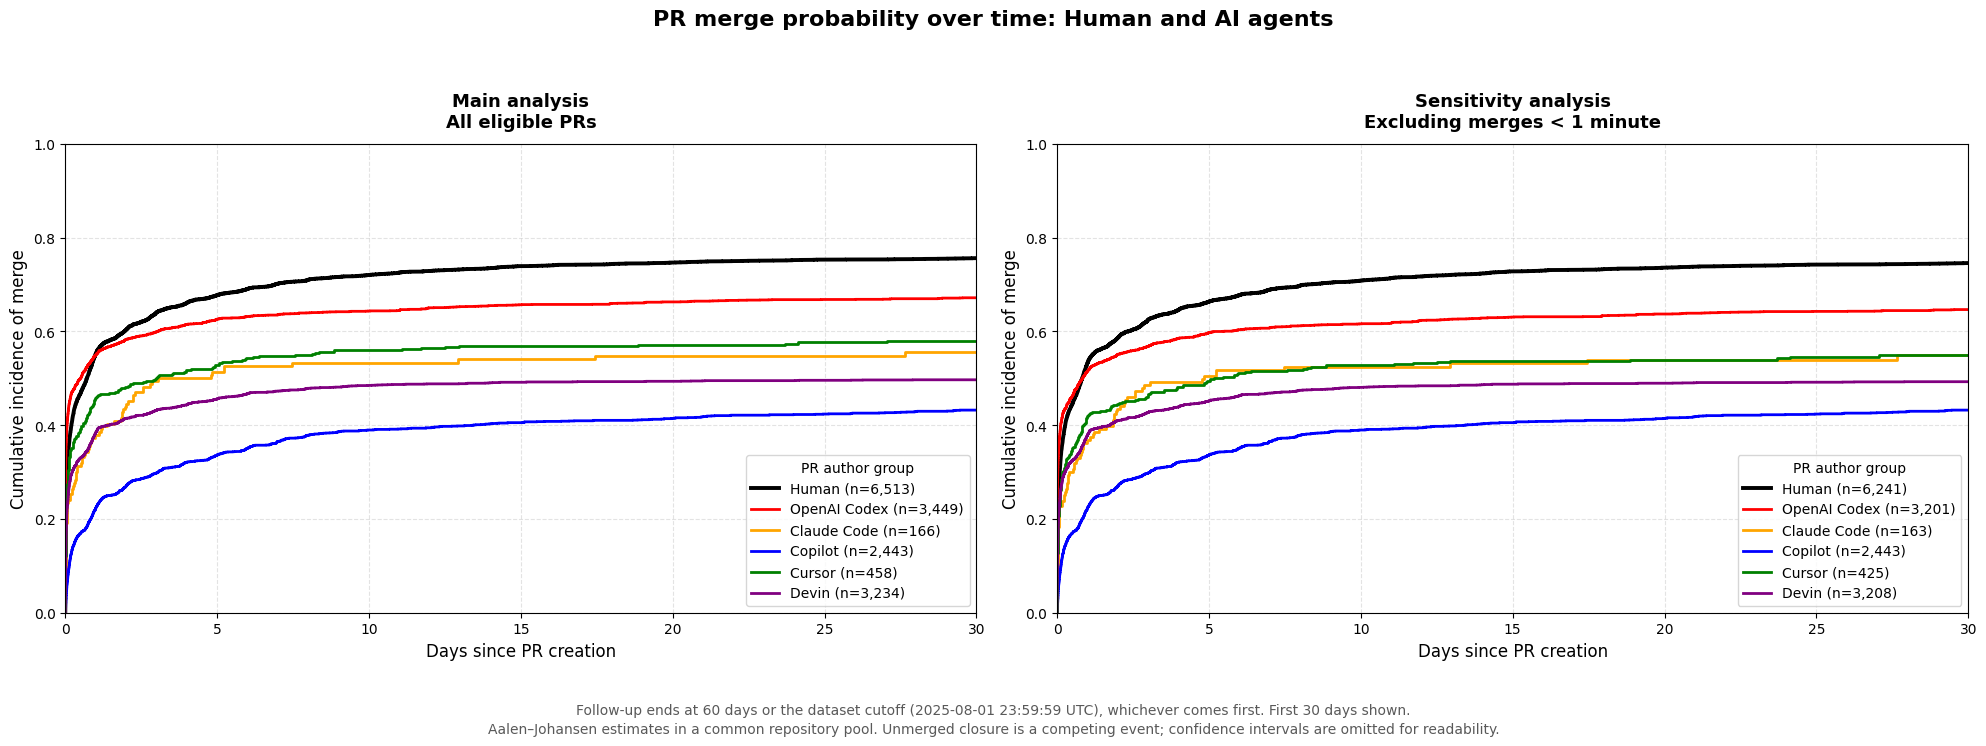

In [5]:
# 4. AJ cumulative incidence: main and sensitivity analyses
# Variance is unnecessary here because confidence intervals are not displayed.
aj_fitter = AalenJohansenFitter(calculate_variance=False, seed=42)


def plot_cohort(cohort_df, ax, title):
    for agent in target_agents:
        agent_data = cohort_df[cohort_df["agent"] == agent]
        if agent_data.empty:
            continue

        aj_fitter.fit(
            durations=agent_data["lag_days"],
            event_observed=agent_data["status_code"],
            event_of_interest=1,
        )
        aj_fitter.plot_cumulative_density(
            ax=ax,
            label=f"{agent_labels[agent]} (n={len(agent_data):,})",
            color=color_map[agent],
            linewidth=2.8 if agent == "Human" else 2.0,
            ci_show=False,
        )

    ax.set_title(title, pad=12)
    style_axis(ax, "Cumulative incidence of merge")
    ax.legend(title="PR author group", loc="lower right")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7.5))
plot_cohort(df_main, ax1, "Main analysis\nAll eligible PRs")
plot_cohort(
    df_sensitivity, ax2,
    "Sensitivity analysis\nExcluding merges < 1 minute",
)

fig.suptitle("PR merge probability over time: Human and AI agents", y=0.98)
fig.text(
    0.5, 0.04, followup_note,
    ha="center", fontsize=10, color="0.35",
)
fig.text(
    0.5, 0.015,
    "Aalen–Johansen estimates in a common repository pool. "
    "Unmerged closure is a competing event; confidence intervals are omitted for readability.",
    ha="center", fontsize=10, color="0.35",
)
fig.tight_layout(rect=(0, 0.09, 1, 0.94))
fig.savefig(FIGURES_DIR / "Aalen_Johansen_CIF.png")
plt.show()


In [6]:
# 5. Descriptive statistics and fixed-time CIF estimates
status_counts = (
    df_valid.groupby(["agent", "status_code"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "Censored", 1: "Merged", 2: "Closed-Unmerged"})
    .reindex(columns=["Censored", "Merged", "Closed-Unmerged"], fill_value=0)
)
status_counts.index.name = "agent"
status_counts.columns.name = None
status_counts["Total_PRs"] = status_counts.sum(axis=1)
status_counts["Crude_Merge_Rate"] = status_counts["Merged"] / status_counts["Total_PRs"]

print(status_counts.to_string(formatters={"Crude_Merge_Rate": "{:.1%}".format}))

# Fixed-time CIF estimates use the full follow-up, not just the plotting window.
timepoints = [7, 30, 60]
cif_records = []
ajf_table = AalenJohansenFitter(calculate_variance=False, seed=42)

for agent in target_agents:
    agent_data = df_valid[df_valid["agent"] == agent]
    if agent_data.empty:
        continue
    ajf_table.fit(
        durations=agent_data["lag_days"],
        event_observed=agent_data["status_code"],
        event_of_interest=1,
    )
    cif = ajf_table.cumulative_density_.iloc[:, 0]
    row = {"Agent": agent}
    for t in timepoints:
        row[f"{t}d CIF"] = cif[cif.index <= t].iloc[-1]
    cif_records.append(row)

cif_table = pd.DataFrame(cif_records).set_index("Agent")
cif_table.index.name = "agent"
print("\nCumulative incidence at fixed timepoints:")
print(cif_table.to_string(float_format="{:.1%}".format))


              Censored  Merged  Closed-Unmerged  Total_PRs Crude_Merge_Rate
agent                                                                      
Claude_Code         26      91               49        166            54.8%
Copilot            512    1064              867       2443            43.6%
Cursor              61     265              132        458            57.9%
Devin              117    1607             1510       3234            49.7%
Human              526    4984             1003       6513            76.5%
OpenAI_Codex       270    2326              853       3449            67.4%

Cumulative incidence at fixed timepoints:
              7d CIF  30d CIF  60d CIF
agent                                 
Human          70.2%    75.6%    76.7%
OpenAI_Codex   63.5%    67.2%    67.8%
Claude_Code    52.7%    55.7%    55.7%
Copilot        36.5%    43.2%    44.8%
Cursor         54.8%    58.0%    58.0%
Devin          47.3%    49.7%    50.1%


/Users/zhengke/Library/Python/3.10/lib/python/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
/Users/zhengke/Library/Python/3.10/lib/python/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
/Users/zhengke/Library/Python/3.10/lib/python/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
/Users/zhengke/Library/Python/3.10/lib/python/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were 

/Users/zhengke/Library/Python/3.10/lib/python/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
/Users/zhengke/Library/Python/3.10/lib/python/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
/Users/zhengke/Library/Python/3.10/lib/python/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
/Users/zhengke/Library/Python/3.10/lib/python/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were 

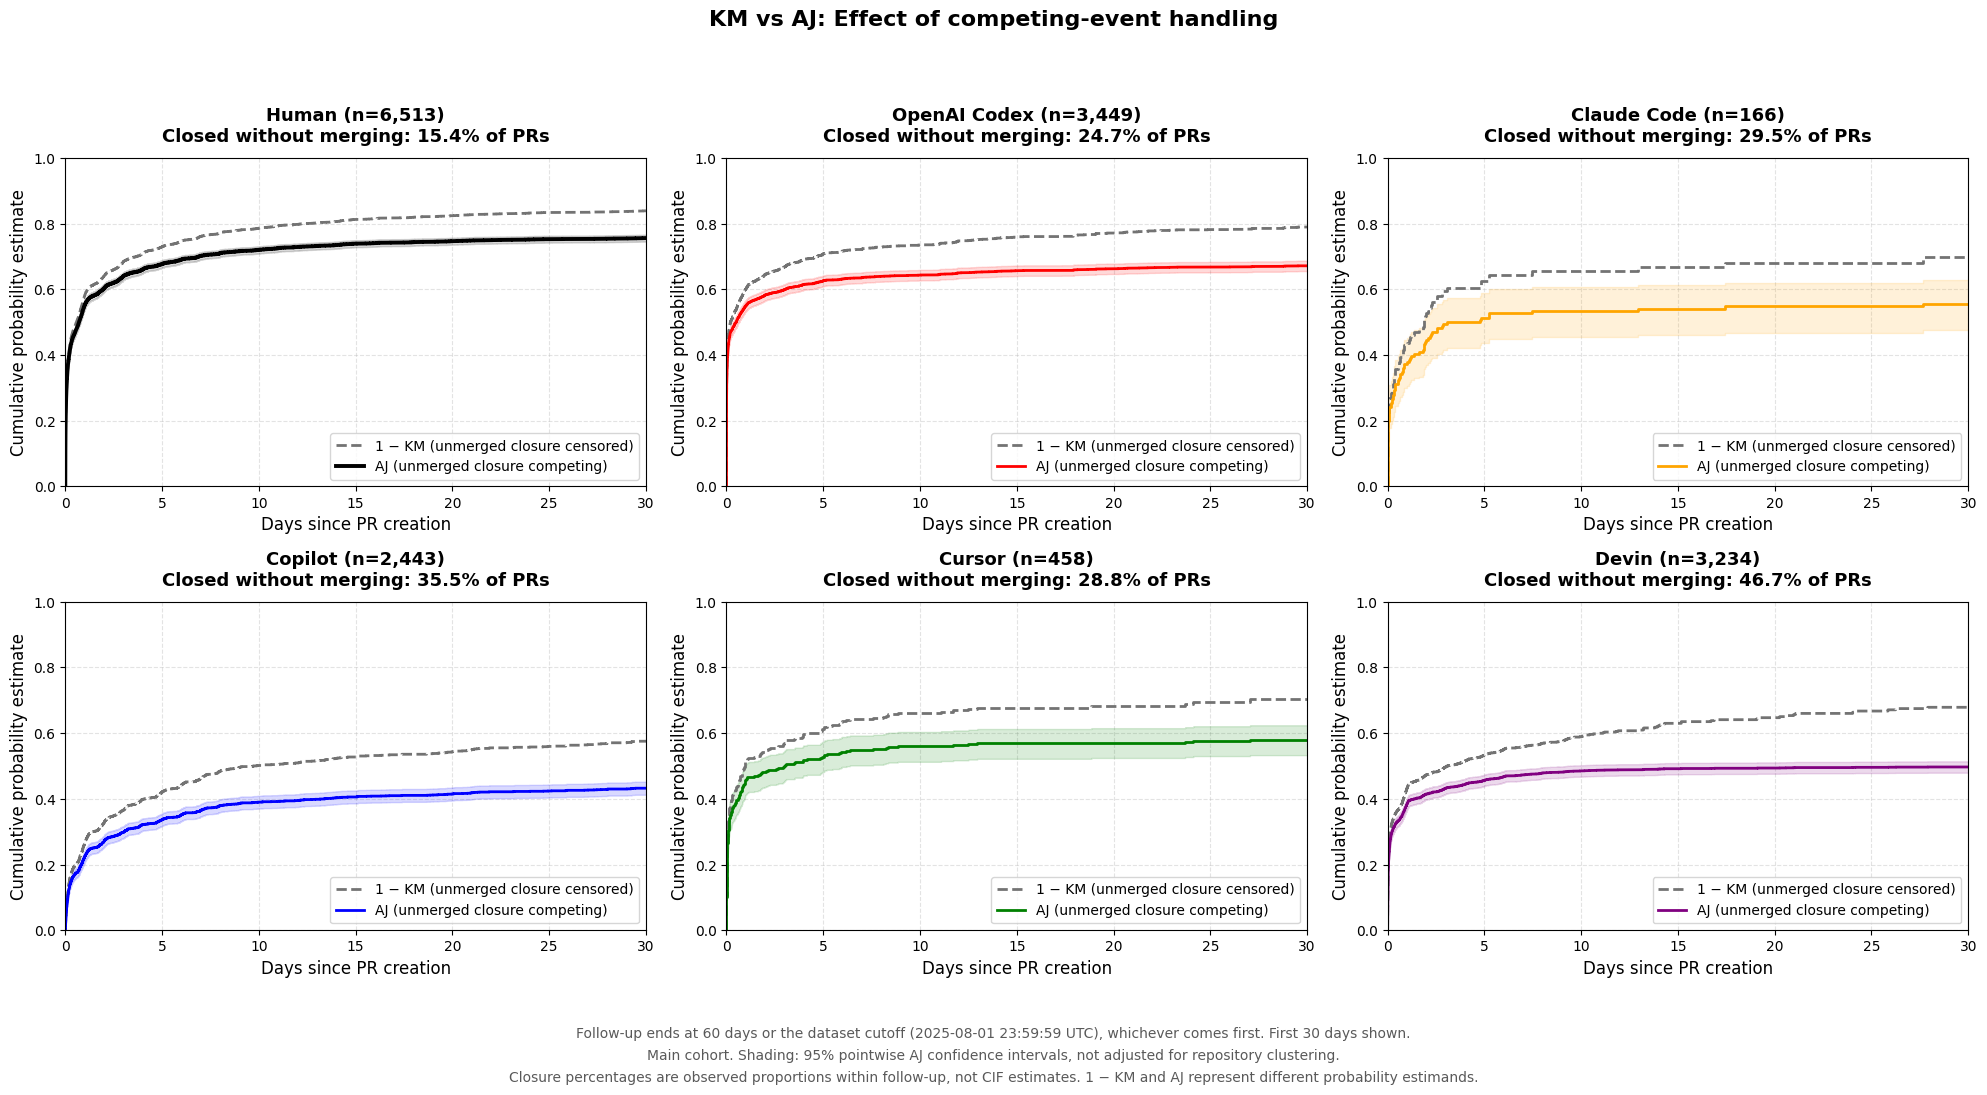

In [7]:
# 6. KM vs AJ: competing-event handling within each author group
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

kmf_all = KaplanMeierFitter(alpha=0.05)
ajf_all = AalenJohansenFitter(calculate_variance=True, alpha=0.05, seed=42)

for ax, agent in zip(axes, target_agents):
    agent_data = df_main[df_main["agent"] == agent]
    if agent_data.empty:
        ax.set_title(f"{agent_labels[agent]} (no data)")
        ax.set_axis_off()
        continue

    kmf_all.fit(
        durations=agent_data["lag_days"],
        event_observed=(agent_data["status_code"] == 1).astype(int),
    )
    kmf_all.plot_cumulative_density(
        ax=ax,
        label="1 − KM (unmerged closure censored)",
        color="0.45",
        linestyle="--",
        linewidth=2.0,
        ci_show=False,
    )

    ajf_all.fit(
        durations=agent_data["lag_days"],
        event_observed=agent_data["status_code"],
        event_of_interest=1,
    )
    ajf_all.plot_cumulative_density(
        ax=ax,
        label="AJ (unmerged closure competing)",
        color=color_map[agent],
        linewidth=2.8 if agent == "Human" else 2.0,
        ci_show=True,
        ci_alpha=0.15,
    )

    close_rate = (agent_data["status_code"] == 2).mean()
    ax.set_title(
        f"{agent_labels[agent]} (n={len(agent_data):,})\n"
        f"Closed without merging: {close_rate:.1%} of PRs",
        pad=12,
    )
    style_axis(ax, "Cumulative probability estimate")
    ax.legend(loc="lower right")

fig.suptitle("KM vs AJ: Effect of competing-event handling", y=0.98)
fig.text(
    0.5, 0.045, followup_note,
    ha="center", fontsize=10, color="0.35",
)
fig.text(
    0.5, 0.025,
    "Main cohort. Shading: 95% pointwise AJ confidence intervals, "
    "not adjusted for repository clustering.",
    ha="center", fontsize=10, color="0.35",
)
fig.text(
    0.5, 0.005,
    "Closure percentages are observed proportions within follow-up, not CIF estimates. "
    "1 − KM and AJ represent different probability estimands.",
    ha="center", fontsize=10, color="0.35",
)
fig.tight_layout(rect=(0, 0.085, 1, 0.94))
fig.savefig(FIGURES_DIR / "Methodology_Comparison_ALL_Agents_KM_vs_AJ.png")
plt.show()


In [8]:
# 7. Export summary tables
status_counts.to_csv(RESULTS_DIR / "summary_table.csv")
cif_table.to_csv(RESULTS_DIR / "cif_table.csv")
print(f"Saved summary_table.csv and cif_table.csv to {RESULTS_DIR}/")


Saved summary_table.csv and cif_table.csv to results/
